# Pytorch Playground

Deep learning framework aid in development and deployment of neural networks. Some of the popular frameworks are JAX, pytorch, and others. Matplotlib and numpy are other framework for visualization and numerical computation.

In [93]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import Subset
from torchvision import datasets, transforms

## Tensors
However, in all the frameworks a data structure called **tensors** is used. The tensors are allocated and initialized using different functions.


In [89]:
x1 = torch.tensor([[2, 1]]) #2-d tensor
x2 = torch.tensor([[1],[2]])
C = torch.mm(x1,x2)
print(C)

tensor([[4]])


Some of the functions are in sub-libraries. e.g. torch.nn.functional.

In [90]:
import torch.nn.functional as F
x2 = torch.tensor([2, 1, -0.5])
relu_out = F.relu(x2)
print(f"ReLU: {relu_out}")

ReLU: tensor([2., 1., 0.])


**Task 1**: Use one of the functions and visualize it with matplotlib.
* zeros()
* ones()
* randn()
* eye()
* others

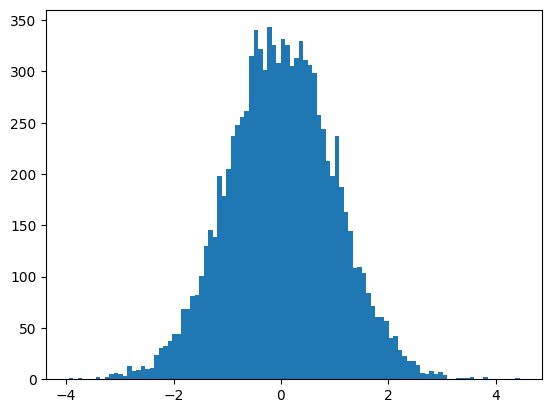

In [91]:
weights = torch.randn(10000)
plt.hist(weights, bins=100)
plt.show()

## Data and Dataset

Training machine learning needs large datasets. These can be images, audio, words, and others represented as tensors. **MNIST** is a data containing grayscale images of handwritten digits (0-9) with resolution of 28x28 pixels. It not only contains images but als ground truth labels.  The dataset has 60,000 training images and 10,000 test images

 The original paper in 1989 used only 7291 training images and 2007 test images of 16x16 pixels.  The images in MNIST Dataset are resized from 28x28 to 16x16. Furthermore, the pixels are scaled from (0,255) to (0,1)

In [112]:
transform = transforms.Compose([
    transforms.Resize((16, 16)),
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_subset_size = 7291
test_subset_size = 2007
train_subset = torch.utils.data.Subset(train_dataset, range(train_subset_size))
test_subset = torch.utils.data.Subset(test_dataset, range(test_subset_size))

Shape is a important concept in deep learning, as it indicates the organization of data, MNIST images in PyTorch are always stored as $C \times H \times W$ (Channels, Height, Width). The image pixel in MNIST is grayscale therefore, the number of channels is 1.



**Task 2** Find out the shape in an MNIST image. Visualize a sample image with its label using matplotlib.

torch.Size([1, 16, 16])
label 7


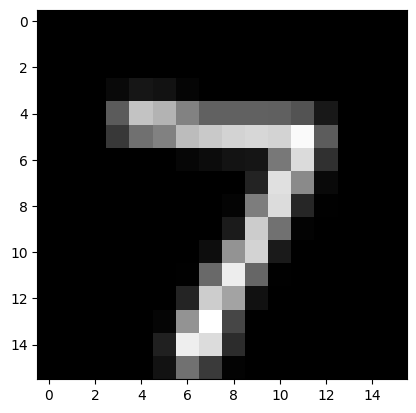

In [109]:
image, label = test_subset[0]
print(image.shape)
plt.imshow(image[0], cmap='gray')
print('label',label)


## Data preprocesing

Data preprocessing plays a major role in Machine Learning training. In the first Lenet paper
* 7291 training image data(16x16) and 2007 test image data are scaled to [-1, 1] from [0,1]
* the labels are one-hot coded. Background is -1. e.g. label 7 is [-1,-1,-1,-1,-1,-1,-1, 1,-1,-1]
* prepreocessed data saved to npz file in /data directory.

In [113]:
train_loader = torch.utils.data.DataLoader(train_subset, batch_size=len(train_subset), shuffle=True)
test_loader = torch.utils.data.DataLoader(test_subset, batch_size=len(test_subset), shuffle=True)
x_train, y_train = next(iter(train_loader))
x_test, y_test = next(iter(test_loader))
dataset_dict = {
    'train': (x_train, y_train, 7291),
    'test': (x_test, y_test, 2007)
}

for split_name, (x_raw, y_raw, n) in dataset_dict.items():
    x_processed = (x_raw[:n] * 2.0) - 1.0
    y_processed = F.one_hot(y_raw[:n], num_classes=10).float()
    y_processed = (y_processed * 2.0) - 1.0
    x_final = x_processed.numpy().astype(np.float32)
    y_final = y_processed.numpy().astype(np.float32)
    filename = f"./data/{split_name}1989.npz"
    np.savez(filename, X=x_final, Y=y_final)
    print(f"   Shape X: {x_final.shape} | Shape Y: {y_final.shape}")


   Shape X: (7291, 1, 16, 16) | Shape Y: (7291, 10)
   Shape X: (2007, 1, 16, 16) | Shape Y: (2007, 10)


**Task 3**: Describe npz format? How can the data in npz file format be read in programming language like C.